In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [6]:
# df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [8]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

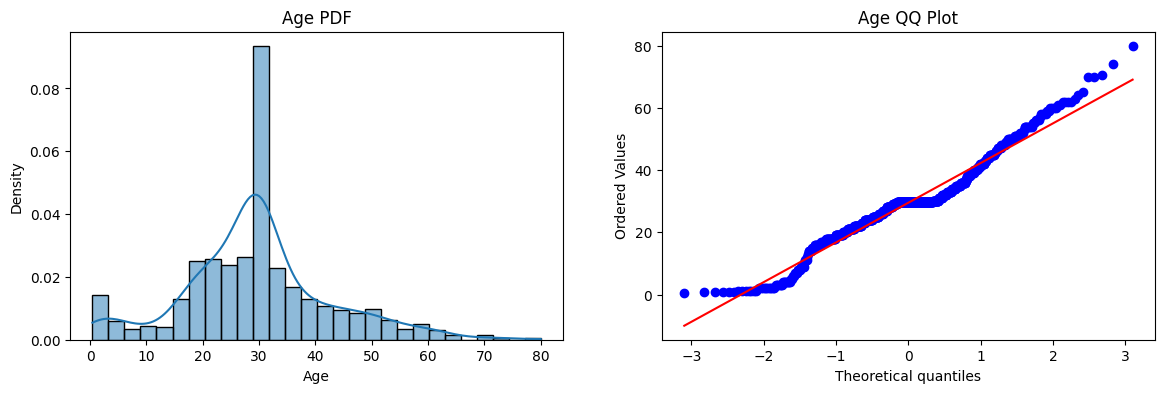

In [14]:
plt.figure(figsize=(14,4))
plt.subplot(121)
# sns.distplot(X_train['Age']) 
sns.histplot(X_train['Age'], kde=True, stat='density')
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

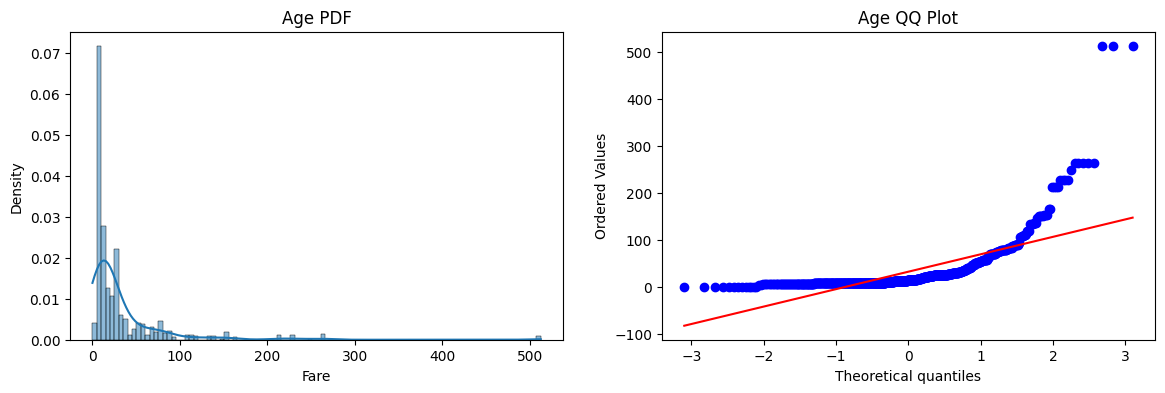

In [16]:
plt.figure(figsize=(14,4))
plt.subplot(121)
# sns.distplot(X_train['Fare'])
sns.histplot(X_train['Fare'], kde=True, stat='density')
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [17]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [18]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.659217877094972


In [19]:
# trf = FunctionTransformer(func=np.log1p, inverse_func=np.expm1) => inverse_func converts the transformed numbers back to their original values
# inverse_func is not needed when we are transforming only input features but its needed when we are transforming regression targets
# np.log() is log(x), np.log1p is log(1+x) - it handles 0s present in the data

trf = FunctionTransformer(func=np.log1p)

In [20]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [21]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.659217877094972


In [22]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6633083645443196


In [23]:
# Transform only 'Fare', pass 'Age' through untouched
trfnew = ColumnTransformer(
    transformers=[
        ('log_fare', FunctionTransformer(np.log1p), ['Fare'])
    ],
    remainder='passthrough'  # Keeps 'Age' unchanged
)

# Fit and transform
X_train_transformednew = trf.fit_transform(X_train)
X_test_transformednew = trf.transform(X_test)

# 3. Train models
clf.fit(X_train_transformednew, y_train)
clf2.fit(X_train_transformednew, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
# This cell is added by me, but it has already been done by CampusX also (scroll down) - 
# we see that before we applied Log transform on both Age and Fare but it should have been done on Age only
# but even on applying on age only, we dont see any improvement in the model, idk why?!

# Cross-validation BEFORE transformation (Raw Data)
lr_scores_raw = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
dt_scores_raw = cross_val_score(clf2, X_train, y_train, cv=5, scoring='accuracy')

# Cross-validation AFTER targeted transformation (Only Fare logged)
lr_scores_transformed = cross_val_score(clf, X_train_transformed, y_train, cv=5, scoring='accuracy')
dt_scores_transformed = cross_val_score(clf2, X_train_transformed, y_train, cv=5, scoring='accuracy')

# Print the mean accuracy comparisons
print("LR: ")
print(f"Before Transform: {np.mean(lr_scores_raw):.4f}")
print(f"After Transform:  {np.mean(lr_scores_transformed):.4f}")

print("\nDT: ")
print(f"Before Transform: {np.mean(dt_scores_raw):.4f}")
print(f"After Transform:  {np.mean(dt_scores_transformed):.4f}")

LR: 
Before Transform: 0.6573
After Transform:  0.6797

DT: 
Before Transform: 0.6096
After Transform:  0.6138


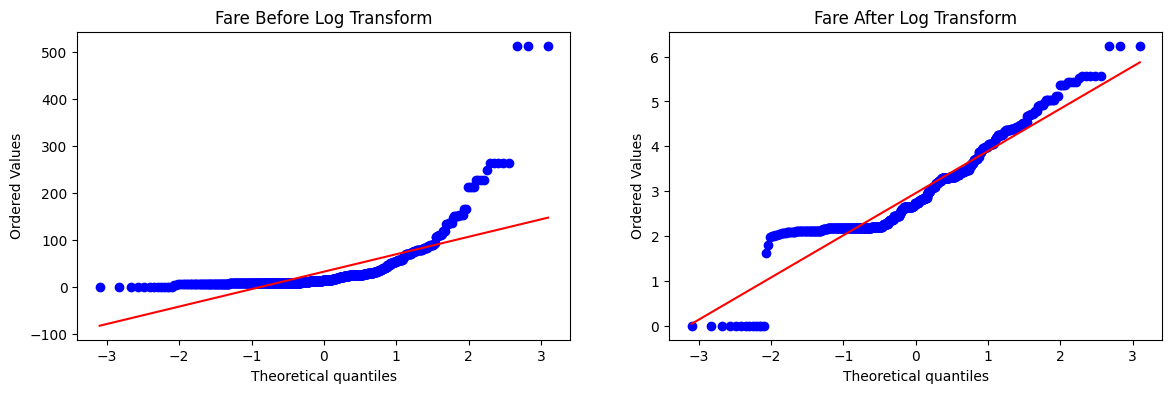

In [25]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log Transform')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log Transform')

plt.show()

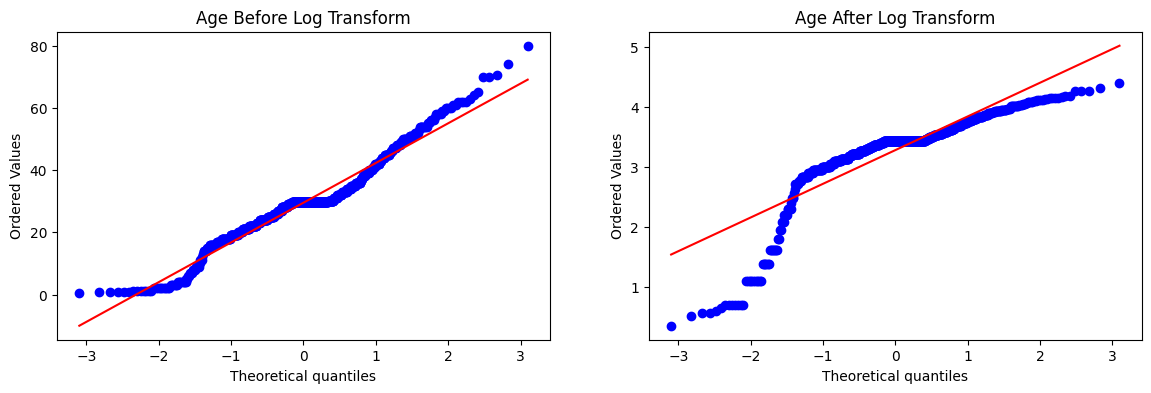

In [27]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log Transform')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log Transform')

plt.show()

# If data is already pretty much normally distributed, applying Log transformation on it will make the data left skewed

In [28]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [29]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6703910614525139


In [30]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6599375780274656


In [33]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6195131086142323


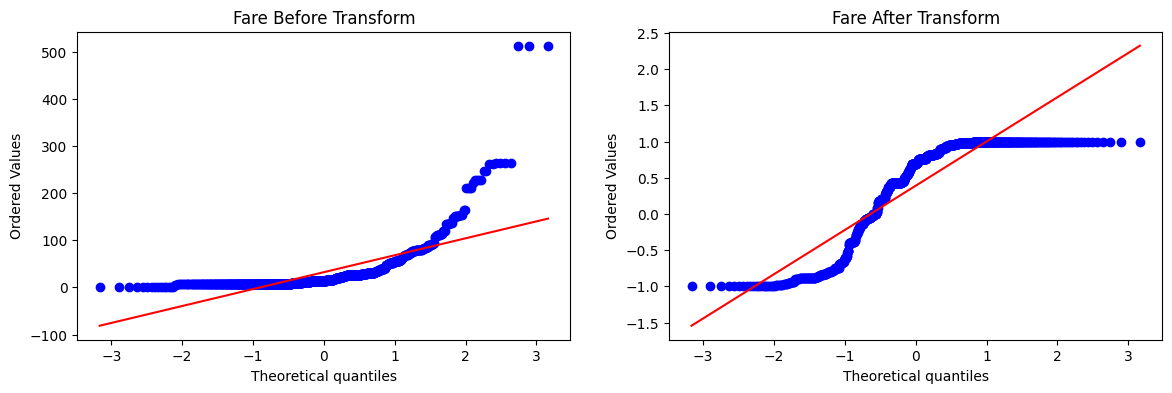

In [34]:
apply_transform(np.sin)

Accuracy 0.6431335830212235


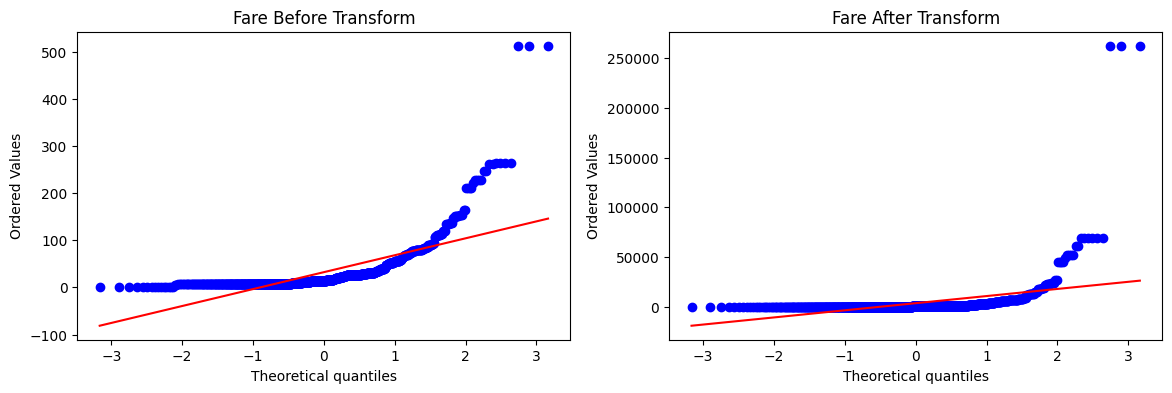

In [35]:
apply_transform(lambda x : x**2)

Accuracy 0.6611485642946316


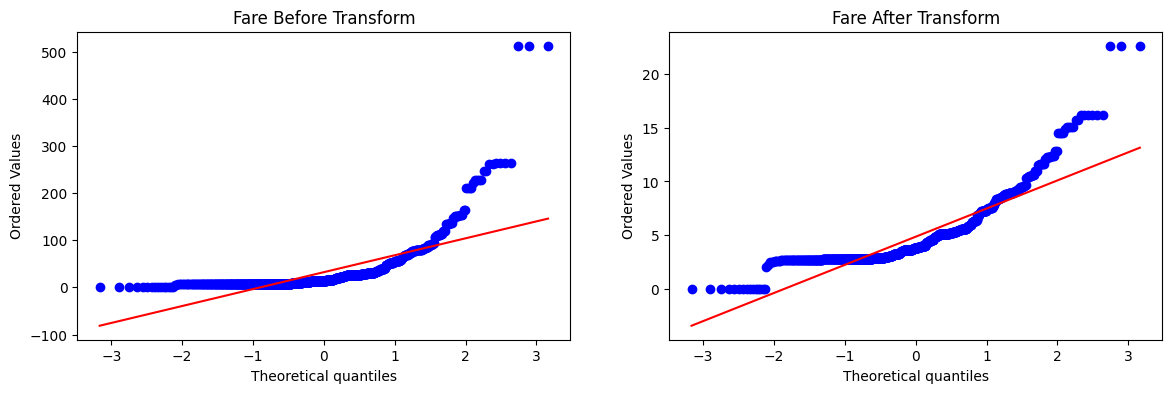

In [36]:
apply_transform(lambda x : x**0.5)

Accuracy 0.61729088639201


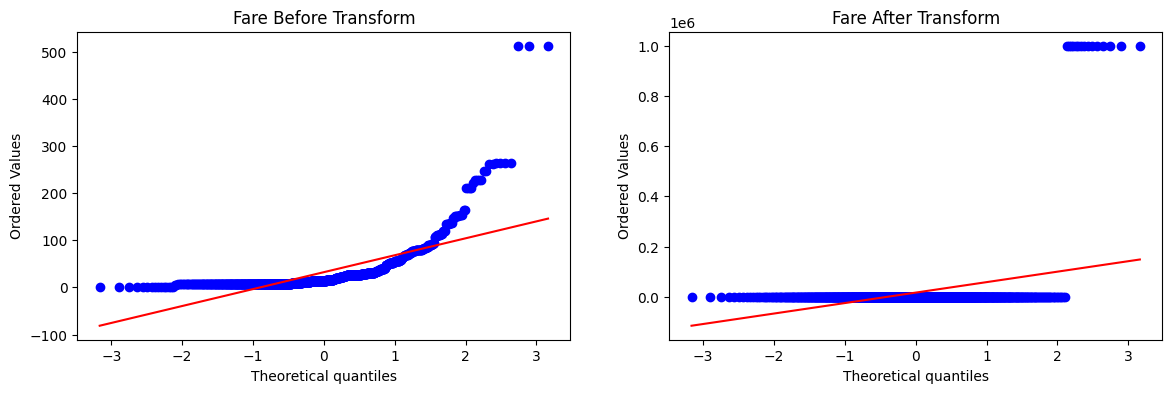

In [40]:
apply_transform(lambda x : 1/(x+0.000001))